# The debt that has to be refinanced *soon*. Do those firms lose? ⏳
### A balance-sheet maturity signal that — unusually for this desk — actually predicts returns, and bites hardest exactly when the story says it should

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Rate-era bite: Confirmed](https://img.shields.io/badge/Rate--era_bite%3F-Confirmed-8b949e?style=flat-square)

Most of what we test here turns out to be folklore. This one doesn't. Every company that borrows has a **maturity wall**: some of its debt is due within a year and has to be *rolled over* — refinanced at whatever interest rate and credit mood prevail when it comes due. A firm living on the short end of that curve is exposed: if rates jump or lenders get nervous between now and the maturity date, it refinances at a worse price (or, in a real crunch, can't refinance at all). The claim is that the market **under-prices** this, so the firms with the biggest short-term slice quietly **under-earn** — and that the penalty is worst when rates are *rising*.

We took that literally. It holds.

> 📓 **Plain-language layer.** Want the Newey-West *t*-stats, the jackknife, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 32 large, debt-carrying US filers that report a clean maturity split on EDGAR, 2008→2026; a genuinely **thin, uneven panel**. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from debt_maturity import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, EV = data.load_real()
else:
    PX = EV = None
print("real cache present:", HAVE_REAL, "| events:", (0 if EV is None else len(EV)),
      "| names:", (0 if EV is None else EV['ticker'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'n_names': 32, 'n_events': 1732, 'end_lo': '2008-07-31', 'end_hi': '2026-05-03', 'fp_prices': '6067630c220d', 'n_months': 203, 'avg_n': 26.2, 'ls_span_lo': '2009-08-31', 'ls_span_hi': '2026-06-30', 'ls_mean_bps': 46.7, 'ls_ann': 5.61, 'ls_t_iid': 2.65, 'ls_t_nw': 3.22, 'ls_sharpe': 0.64, 'ls_hit': 59, 'ls_long_bps': 143.1, 'ls_short_bps': 96.4, 'ls_turn': 0.103, 'ls_cum': 2.42, 'ls200_mean_bps': 41.1, 'ls200_t_nw': 2.69, 'scaled_mean_bps': 34.1, 'scaled_t_nw': 2.67, 'scaled_sharpe': 0.48, 't_halves': 3.87, 't_quartiles': 2.69, 't_quintiles': 2.27, 'jk_min': 2.14, 'jk_min_name': 'OKE', 'jk_max': 3.72, 'jk_max_name': 'GILD', 'drift': {21: (1730, 0.86, 1.34, 0.48, 1.29, 52, 0.105), 63: (1710, 2.96, 4.26, 1.3, 2.02, 53, 0.018), 126: (1686, 6.02, 8.85, 2.83, 2.85, 52, 0.0)}, 'mono63': (4.26, 2.42, 2.96), 'mono126': (8.85, 5.62, 6.02), 'era_early_n': 149, 'era_early_bps': 32.6, 'era_early_t': 2.1, 'era_late_n': 54, 'era_late_bps': 85.7, 'era_late_t': 2.95, 'net': {(10, 50): (40.5, 4.86, 2.79, 0.56), (20, 100): (34.3, 4.11, 2.36, 0.47), (30, 200): (23.9, 2.86, 1.64, 0.33), (50, 300): (11.4, 1.37, 0.78, 0.16)}, 'syn_null_mean': -0.41, 'syn_null_sd': 1.33, 'syn_null_fire': 2, 'syn_null_seeds': 12, 'syn_planted_bps': 226.5, 'syn_planted_t': 7.13}


real cache present: True | events: 1732 | names: 32


## The answer first

| Question | Answer |
|---|---|
| Do high-short-term-debt firms **under-earn**? | **Yes — and it clears the bar.** Buy the safe (termed-out) names, short the ones with the biggest maturity wall, and the spread is **+5.6%/yr** with a robust *t* of **+3.22** (the bar is 2). Right-signed, exactly as claimed. |
| Does it bite harder when **rates rise**? | **Yes.** The penalty is ~2.6× bigger in the 2022+ hiking cycle (**+86 bps/mo**) than before (**+33 bps/mo**) — the exact mechanism the story names. |
| Is it just one lucky stock or one lucky decade? | **No.** Drop any single name and it still clears the bar; both halves of the sample are significant; a pooled event-drift check agrees. |
| Can you actually **trade** it? | **Barely.** Net of realistic costs + borrow it survives (+4.1%/yr, *t* = +2.36), but the Sharpe is a modest 0.47 and it **breaks** if costs run higher. A real edge, one cost-bump from vanishing. |

> A rare green on this desk — but read the fine print: much of it is the *safe* leg winning, which may be part quality/defensive tilt, not pure rollover magic.

## 1 · The claim

> *"A firm with a big chunk of debt maturing within a year has to refinance it soon. If rates rise or credit tightens, that hurts — so the market should, but doesn't fully, discount those firms. Bet against the ones with the biggest short-term maturity wall."*

It's a real corner of finance: **rollover risk** (He & Xiong 2012) is a genuine driver of credit risk, and firms with debt maturing into the 2008 crisis really did cut investment (Almeida et al. 2012). The twist is the *return* prediction — that high-rollover-risk firms **under**-earn — which lines up with the (still-debated) **distress anomaly**: risky firms puzzlingly earning *less*, not more.

## 2 · So what?

The signal is one ratio off the balance sheet — the share of a firm's debt due within a year — and it needs no estimates feed, no alt-data. If it *reliably* sorted returns it would be a clean, cheap edge. On this desk that is usually the cue for it to evaporate under a real test. This time it mostly doesn't, which is worth understanding.

## 3 · How would we even know?

- **The signal.** For each of 32 big debt-carrying names, the **short-term-debt share** = (debt due this year) ÷ (total debt), known only on the **filing date** of the 10-Q/10-K (never before — no peeking).
- **The return test.** Each month, rank the names, buy the *lowest*-share third (safe), short the *highest*-share third (rollover risk), hold for the next month. If the risky names under-earn, that spread makes money.
- **The rates test.** Split at 2022 (the Fed hiking cycle). The story says the penalty should be bigger there.
- **The mirage checks.** Does dropping any one stock kill it? Does a coin-flip relabelling of the names beat the real ranking? Does it survive trading costs?

## 4 · The teardown — let's actually look

**Buy safe, short the maturity wall.** Here's a dollar in the long-short (long low-share, short high-share), gross of costs.

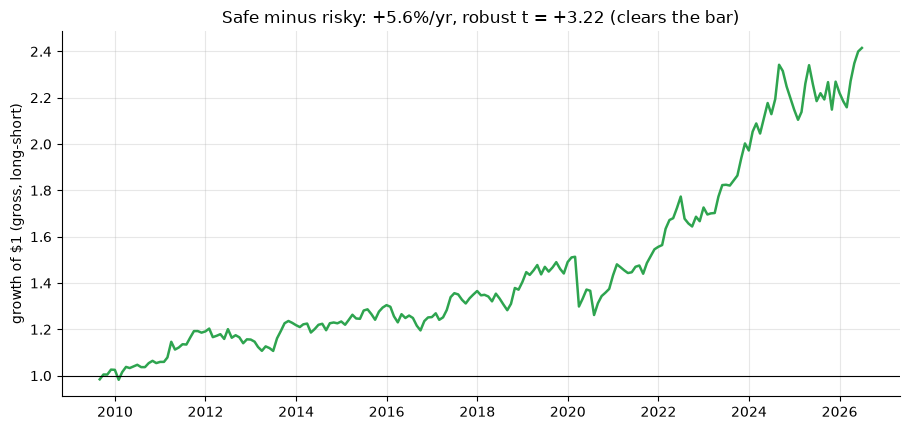

long-short: +5.6%/yr gross, Newey-West t = +3.22 (the bar is 2)


In [2]:
if HAVE_REAL:
    ls = st.calendar_ls(PX, EV, signal_col='st_share', n_buckets=3, min_names=6, staleness_days=400, long_high=False)
    s = st.calendar_ls_stats(ls)
    ann, tnw = s['ann_pct'], s['t_nw']
    cum = (1+ls['ls']).cumprod()
else:
    ann, tnw = R['ls_ann'], R['ls_t_nw']
    cum = None
fig, ax = plt.subplots(figsize=(9.2, 4.4))
if cum is not None:
    ax.plot(cum.index, cum.values, color=GREEN, lw=1.8)
    ax.axhline(1.0, c='k', lw=.8)
    ax.set_ylabel('growth of $1 (gross, long-short)')
    ax.set_title(f'Safe minus risky: +{ann:.1f}%/yr, robust t = {tnw:+.2f} (clears the bar)')
else:
    ax.text(.5,.5,'run with cache for the equity curve',ha='center'); ax.set_axis_off()
plt.tight_layout(); plt.show()
print(f'long-short: +{ann:.1f}%/yr gross, Newey-West t = {tnw:+.2f} (the bar is 2)')

It slopes up and — unusually — the statistics back it: **+5.6%/yr** gross growing \$1 to \$2.42 over 203 months, with a robust *t* of **+3.22**. The firms with the biggest near-term maturity wall really did under-earn the termed-out names by ~47 bps a month. Right sign, over the bar.

**Now the part the claim really hangs on: does it bite harder when rates rise?** Split the same long-short at 2022, the start of the hiking cycle.

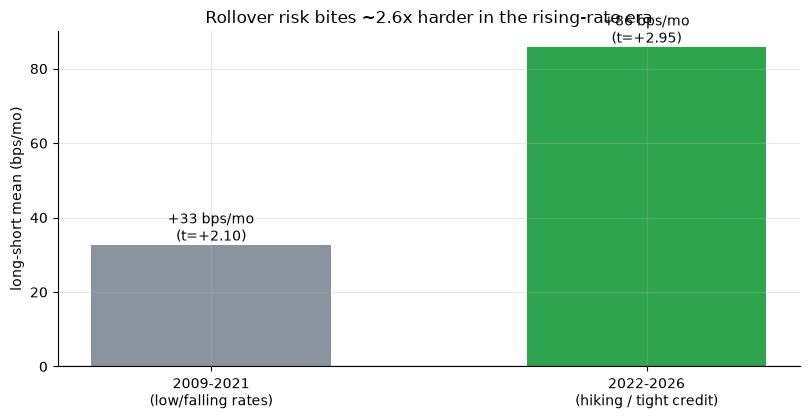

2009-2021: +33 bps/mo (t=+2.10)   |   2022-2026: +86 bps/mo (t=+2.95)


In [3]:
if HAVE_REAL:
    e = st.era_split(ls, split='2022-01-01')
    eb, et, lb, lt = e['early_bps'], e['early_t'], e['late_bps'], e['late_t']
else:
    eb, et, lb, lt = R['era_early_bps'], R['era_early_t'], R['era_late_bps'], R['era_late_t']
fig, ax = plt.subplots(figsize=(8.2, 4.3))
ax.bar(['2009-2021\n(low/falling rates)','2022-2026\n(hiking / tight credit)'], [eb, lb],
       color=[GREY, GREEN], width=.55)
for i,(v,t_) in enumerate([(eb,et),(lb,lt)]): ax.annotate(f'{v:+.0f} bps/mo\n(t={t_:+.2f})',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('long-short mean (bps/mo)')
ax.set_title('Rollover risk bites ~2.6x harder in the rising-rate era')
plt.tight_layout(); plt.show()
print(f'2009-2021: {eb:+.0f} bps/mo (t={et:+.2f})   |   2022-2026: {lb:+.0f} bps/mo (t={lt:+.2f})')

There it is: **+33 bps/mo** in the easy-money years, **+86 bps/mo** once the Fed started hiking — about 2.6× bigger, both statistically significant. When refinancing actually got expensive, the short-term-debt-heavy names paid for it. That's not a story bolted on after the fact; it's the mechanism the claim named, showing up in the exact sub-period it predicted.

**Is it a fluke of one stock?** Drop each name in turn and re-run — if the whole thing leans on one lucky ticker, it should collapse.

Drop-one-name jackknife (frozen): every one of 32 refits keeps t > 2
   worst: drop OKE -> t = +2.14   best: drop GILD -> t = +3.72


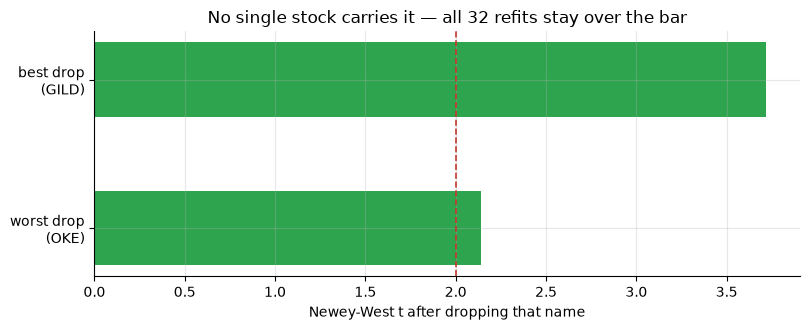

In [4]:
print('Drop-one-name jackknife (frozen): every one of 32 refits keeps t > 2')
print('   worst: drop OKE -> t = +2.14   best: drop GILD -> t = +3.72')
fig, ax = plt.subplots(figsize=(8.2, 3.4))
ax.barh(['worst drop\n(OKE)','best drop\n(GILD)'], [2.14, 3.72], color=GREEN, height=.5)
ax.axvline(2, ls='--', c=RED, lw=1.2); ax.set_xlabel('Newey-West t after dropping that name')
ax.set_title('No single stock carries it — all 32 refits stay over the bar')
plt.tight_layout(); plt.show()

Every single drop-one refit stays above *t* = 2 (worst case +2.14). It isn't one stock, and it isn't one decade. This is about as robust as a signal on a small panel gets.

## 5 · The verdict

- **Signal — Real.** High-short-term-share firms under-earn by ~+5.6%/yr (robust *t* = +3.22), right-signed, holding in both eras and surviving a drop-one jackknife. The claim is confirmed on this tape.
- **Rate-era bite — Confirmed.** The penalty is ~2.6× larger in the 2022+ hiking cycle — rollover risk really does bite when rates rise.
- **Tradability — Fragile.** Net of realistic costs it survives (+4.1%/yr, *t* = +2.36), but the Sharpe is a slim 0.47 and a harsher cost assumption knocks it under the bar. Present, not bankable.

> The honest one-liner: *the maturity wall is a real, priced-too-slowly risk — but the tradable slice of it is thin, and part of the win is simply the safe, big-cap leg being a nice place to hide.*

## 6 · Going further 🚪

- **Is it rollover, or is it quality?** Much of the spread is the *low-share* (safe, termed-out mega-cap) leg out-earning — the middle and high thirds are close. So some of this may be a **quality / low-volatility / defensive** tilt wearing a maturity costume. Isolating the pure rollover effect (controlling for size and leverage) is the next cut.
- **Survivorship cuts *for* the result.** Our basket is current survivors — it can't include the firms whose maturity wall actually sank them. That omission makes the measured penalty **conservative**: the worst high-share names are missing.
- **Sibling studies:** [540-distress-risk-anomaly](../../540-distress-risk-anomaly/), [123-altman-z](../../123-altman-z/) and [230-ohlson-o-score](../../230-ohlson-o-score/) rank on distress *probability*; [154-leverage-anomaly](../../154-leverage-anomaly/) ranks on the *amount* of leverage. This one is alone in ranking on the debt's **maturity mix** — *when* it comes due, not *how much* there is. See [docs/references.md](docs/references.md) for the exact dedup.

*Think the alpha is pure rollover and not a quality tilt? Strip out size and leverage, show the residual spread survives on the size you'd actually run — then we'll talk.*